# **Deep Learning Lab: Transfer Learning**

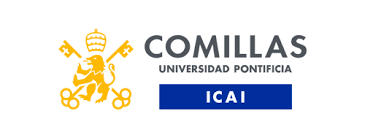

***

## Import packages

In [1]:
from cnn import CNN
import torchvision
from cnn import load_data
from cnn import load_model_weights
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import json

In [2]:
#pip install wandb

In [3]:
#!wandb login

In [4]:
#!wandb login --relogin

## Model and data loading

In [5]:
# Pytorch has many pre-trained models that can be used for transfer learning
classification_models = torchvision.models.list_models(module=torchvision.models)
print(classification_models)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [6]:
# Load data and model 
train_dir = './dataset/training'
valid_dir = './dataset/validation'

train_loader, valid_loader, num_classes = load_data(train_dir, 
                                                    valid_dir, 
                                                    batch_size=32, 
                                                    img_size=224) # ConvNeXt-Base requires 224x224 images
model = CNN(torchvision.models.convnext_base(weights='DEFAULT'), num_classes, unfreezed_layers=8)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to C:\Users\julia/.cache\torch\hub\checkpoints\convnext_base-6075fbad.pth


100.0%


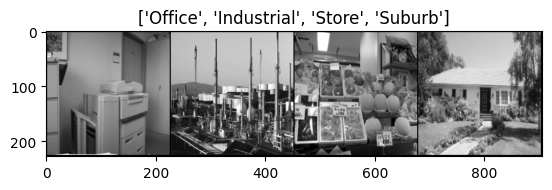

In [7]:
# Visualize a few images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(valid_loader.dataset[i][1])
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])

## Train

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
history = model.train_model(train_loader, valid_loader, optimizer, criterion, epochs=8, use_wandb=True, wandb_config={"dataset": "Scene Classification", "model": "ConvNeXt-Base", "lr": "3e-5", "optimizer": "AdamW", "weight_decay": 0.01}, architecture="ConvNeXt-Base")

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: juliacano (javi_paula_julia). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Epoch 1/8 - Train Loss: 1.7405, Train Accuracy: 0.4616
Epoch 1/8 - Validation Loss: 0.6529, Validation Accuracy: 0.8300
Epoch 2/8 - Train Loss: 0.6548, Train Accuracy: 0.7960
Epoch 2/8 - Validation Loss: 0.3067, Validation Accuracy: 0.9087
Epoch 3/8 - Train Loss: 0.4872, Train Accuracy: 0.8466
Epoch 3/8 - Validation Loss: 0.2563, Validation Accuracy: 0.9073
Epoch 4/8 - Train Loss: 0.4042, Train Accuracy: 0.8690
Epoch 4/8 - Validation Loss: 0.1797, Validation Accuracy: 0.9427
Epoch 5/8 - Train Loss: 0.3542, Train Accuracy: 0.8791
Epoch 5/8 - Validation Loss: 0.1785, Validation Accuracy: 0.9380
Epoch 6/8 - Train Loss: 0.3150, Train Accuracy: 0.9025
Epoch 6/8 - Validation Loss: 0.1699, Validation Accuracy: 0.9380
Epoch 7/8 - Train Loss: 0.2975, Train Accuracy: 0.9039
Epoch 7/8 - Validation Loss: 0.1703, Validation Accuracy: 0.9373
Epoch 8/8 - Train Loss: 0.2840, Train Accuracy: 0.9069
Epoch 8/8 - Validation Loss: 0.1603, Validation Accuracy: 0.9453


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


In [9]:
model.save('convnext_base-8epoch')

## Predict

#### Load model

In [10]:
# Load model
model_weights = load_model_weights('convnext_base-8epoch')
my_trained_model = CNN(torchvision.models.convnext_base(weights='DEFAULT'), num_classes, unfreezed_layers=8)
my_trained_model.load_state_dict(model_weights)

<All keys matched successfully>

## Results

In [11]:
predicted_labels = my_trained_model.predict(valid_loader)

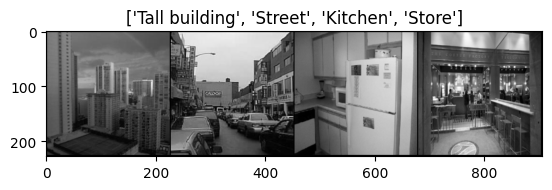

In [12]:
# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(predicted_labels[i])

out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])
